In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [113]:
from src.data_manager import DataManager

group_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/em/fibsem-uint8/' 
seg_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/labels/mito_seg/'

# Configuration
em_resolution = 's1' # 8x8x8 nm voxels
segmentation_resolution = 's0' # 8x8x8 nm voxels

data_manager = DataManager(group_url, seg_url, em_resolution, segmentation_resolution)

/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


In [114]:
data_manager.em_data.view_groups()

(
    ('s0', <zarr.core.Array '/em/fibsem-uint8/s0' (8932, 12728, 12747) uint8 read-only>),
    ('s1', <zarr.core.Array '/em/fibsem-uint8/s1' (4466, 6364, 6373) uint8 read-only>),
    ('s10', <zarr.core.Array '/em/fibsem-uint8/s10' (8, 12, 12) uint8 read-only>),
    ('s11', <zarr.core.Array '/em/fibsem-uint8/s11' (4, 6, 6) uint8 read-only>),
    ('s12', <zarr.core.Array '/em/fibsem-uint8/s12' (2, 3, 3) uint8 read-only>),
    ('s2', <zarr.core.Array '/em/fibsem-uint8/s2' (2233, 3182, 3186) uint8 read-only>),
    ('s3', <zarr.core.Array '/em/fibsem-uint8/s3' (1116, 1591, 1593) uint8 read-only>),
    ('s4', <zarr.core.Array '/em/fibsem-uint8/s4' (558, 795, 796) uint8 read-only>),
    ('s5', <zarr.core.Array '/em/fibsem-uint8/s5' (279, 397, 398) uint8 read-only>),
    ('s6', <zarr.core.Array '/em/fibsem-uint8/s6' (139, 198, 199) uint8 read-only>),
    ('s7', <zarr.core.Array '/em/fibsem-uint8/s7' (69, 99, 99) uint8 read-only>),
    ('s8', <zarr.core.Array '/em/fibsem-uint8/s8' (34, 49, 49) uint8 read-only>),
    ('s9', <zarr.core.Array '/em/fibsem-uint8/s9' (17, 24, 24) uint8 read-only>)
)

In [115]:
data_manager.segmentation_data.view_groups()

(
    ('s0', <zarr.core.Array '/labels/mito_seg/s0' (4466, 6364, 6372) uint32 read-only>),
    ('s1', <zarr.core.Array '/labels/mito_seg/s1' (2233, 3182, 3186) uint32 read-only>),
    ('s2', <zarr.core.Array '/labels/mito_seg/s2' (1116, 1591, 1593) uint32 read-only>),
    ('s3', <zarr.core.Array '/labels/mito_seg/s3' (558, 795, 796) uint32 read-only>),
    ('s4', <zarr.core.Array '/labels/mito_seg/s4' (279, 397, 398) uint32 read-only>),
    ('s5', <zarr.core.Array '/labels/mito_seg/s5' (139, 198, 199) uint32 read-only>),
    ('s6', <zarr.core.Array '/labels/mito_seg/s6' (69, 99, 99) uint32 read-only>)
)

In [41]:
from src.visualizer import Visualizer

vis = Visualizer(data_manager)

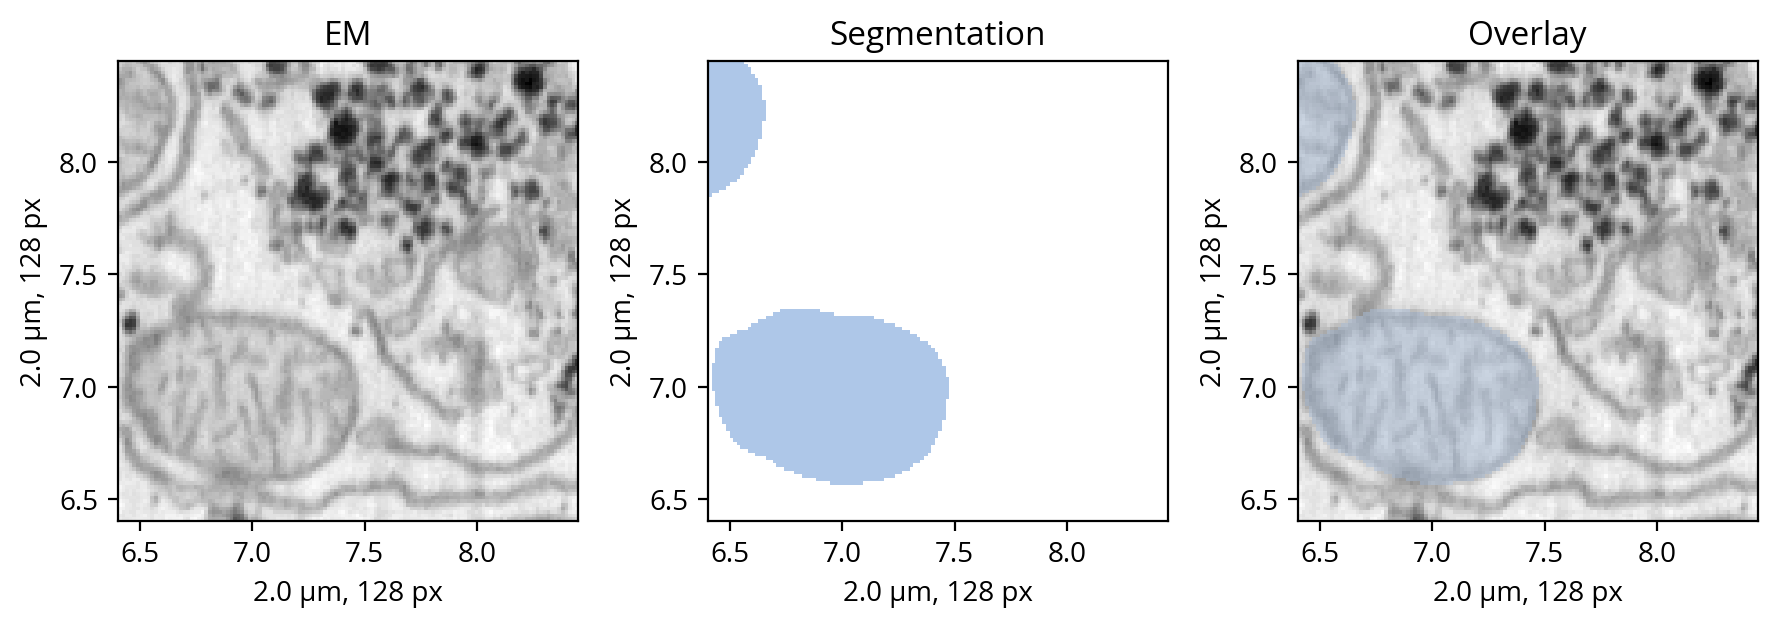

In [116]:
from src.slice import Slice3D

# Define a region of interest                                                                                                           
slc = Slice3D(
  z=slice(400, 528),
  y=slice(400, 528),
  x=slice(400, 528),
)                                      

z_index_to_plot = 420

# 2D plot — pick any z index within the slice bounds                                                                                    
vis.plot_segmentation_example(slc, z_index=z_index_to_plot)


In [142]:
# 128 patch sizes divisible by 16 (8 patches for DINOv3).
# Also 128 pixels (@16 nm voxels for s1) ~ 2 microns
# Mitochondria are 0.5-1 microns
patch_size = 128 # pixels

# Now we have the information we need to slice our volume into images.

# Z-step is determined by the size of the mitochondria—we are minimizing
# duplicate mitochondria patches by stepping across mitochondria.

# for simplicity, we'll step by 2 microns (the same size of the image patches).
# todo: this may skip mitochondria entirely, so adjust this if we need to.
z_step = 128 # voxels 

from src.slice_generator import SliceGenerator

slicer = SliceGenerator(data_manager, patch_size, z_step, 128)

In [143]:
slices = slicer.generate()

In [144]:
slices[0:10]

[Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(128, 256, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(256, 384, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(384, 512, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(512, 640, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(640, 768, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(768, 896, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(896, 1024, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(1024, 1152, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(1152, 1280, None)),
 Slice at (z:slice(128, 128, None), y:slice(128, 256, None), x:slice(1280, 1408, None))]

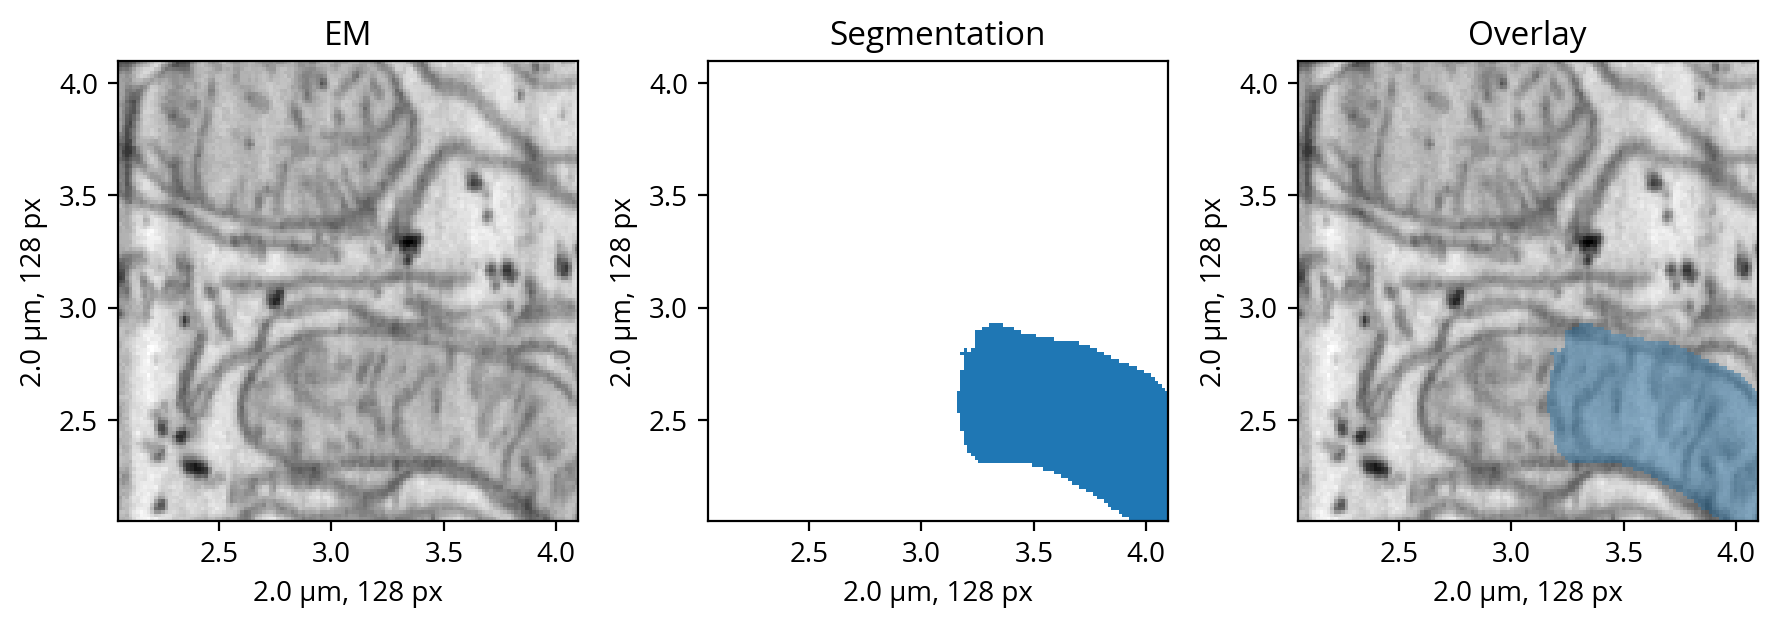

In [146]:
from src.slice import Slice3D

# Define a region of interest                                                                                                           
slc = slices[0]

z_index_to_plot = slc.z.start

# 2D plot — pick any z index within the slice bounds                                                                                    
vis.plot_segmentation_example(slc, z_index=z_index_to_plot)
